<a href="https://colab.research.google.com/github/tasnimmahin21-sudo/Database-and-Analytics-Assignment/blob/main/Python_Data_Processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Investigate how vehicle battery health correlates with incident severity and delivery success.

--- Operational Status vs Battery Health ---


,delivery_status,Avg_Battery_Health,Total_Incidents
0,Delayed,76.772414,55
1,Failed,75.615556,34
2,OnTime,77.042395,191


/tmp/ipykernel_12018/2335627806.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=full_ops.dropna(subset=['severity']), x='severity', y='battery_health_pct', palette='coolwarm')


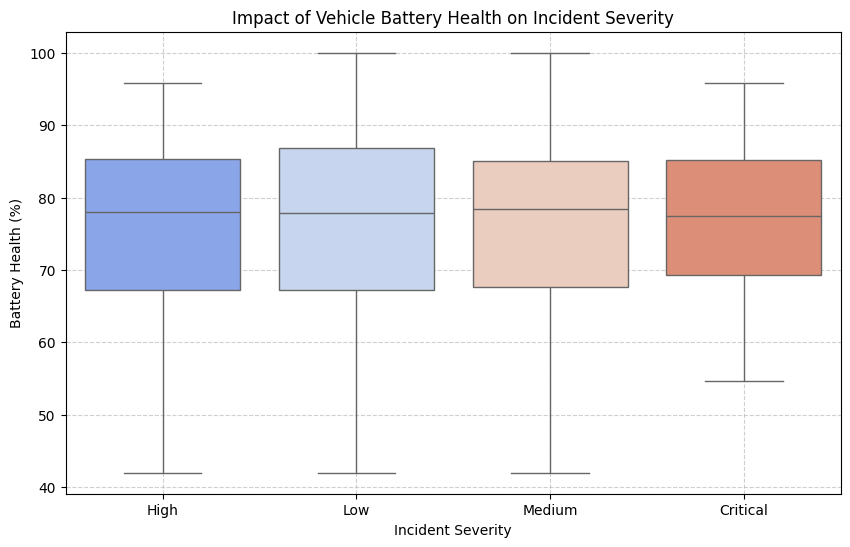

In [ ]:
# Install visualization libraries
!pip install pandas numpy matplotlib seaborn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Define the exact GitHub Raw Base URL
base_url = 'https://raw.githubusercontent.com/tasnimmahin21-sudo/Database-and-Analytics-Assignment/refs/heads/main/'

# 2. Load datasets directly from repository
deliveries_df = pd.read_csv(base_url + 'deliveries.csv')
incidents_df = pd.read_csv(base_url + 'incidents.csv')
vehicles_df = pd.read_csv(base_url + 'vehicles.csv')

# Clean inconsistent data
vehicles_df['assigned_zone'] = vehicles_df['assigned_zone'].str.upper()

# Merge Vehicles, Deliveries, and Incidents
veh_del = pd.merge(deliveries_df, vehicles_df, on='vehicle_id', how='left')
full_ops = pd.merge(veh_del, incidents_df, on='delivery_id', how='left')

# Analyse the impact of battery health on delivery failures
battery_analysis = full_ops.groupby('delivery_status').agg(
    Avg_Battery_Health=('battery_health_pct', 'mean'),
    Total_Incidents=('incident_id', 'count')
).reset_index()

print("--- Operational Status vs Battery Health ---")
display(battery_analysis)

# Visualisation: Battery Health vs Incident Severity
plt.figure(figsize=(10, 6))
sns.boxplot(data=full_ops.dropna(subset=['severity']), x='severity', y='battery_health_pct', palette='coolwarm')
plt.title('Impact of Vehicle Battery Health on Incident Severity')
plt.xlabel('Incident Severity')
plt.ylabel('Battery Health (%)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()